In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [3]:
from google.colab import files

uploaded = files.upload()

Saving suppliers_cleaned.csv to suppliers_cleaned.csv
Saving returns_cleaned.csv to returns_cleaned.csv
Saving products_cleaned.csv to products_cleaned.csv
Saving payments_cleaned.csv to payments_cleaned.csv
Saving orders_cleaned.csv to orders_cleaned.csv
Saving order_items_cleaned.csv to order_items_cleaned.csv
Saving inventory_cleaned.csv to inventory_cleaned.csv
Saving customers_cleaned.csv to customers_cleaned.csv


In [4]:
import os

files_list = [
    "customers_cleaned.csv",
    "products_cleaned.csv",
    "payments_cleaned.csv",
    "order_items_cleaned.csv",
    "orders_cleaned.csv",
    "returns_cleaned.csv",
    "suppliers_cleaned.csv",
    "inventory_cleaned.csv"
]

for file in files_list:
    print(file, "→", os.path.exists(file))

customers_cleaned.csv → True
products_cleaned.csv → True
payments_cleaned.csv → True
order_items_cleaned.csv → True
orders_cleaned.csv → True
returns_cleaned.csv → True
suppliers_cleaned.csv → True
inventory_cleaned.csv → True


In [5]:
import pandas as pd

customers = pd.read_csv("customers_cleaned.csv")
products = pd.read_csv("products_cleaned.csv")
payments = pd.read_csv("payments_cleaned.csv")
order_items = pd.read_csv("order_items_cleaned.csv")
orders = pd.read_csv("orders_cleaned.csv")
returns = pd.read_csv("returns_cleaned.csv")
suppliers = pd.read_csv("suppliers_cleaned.csv")
inventory = pd.read_csv("inventory_cleaned.csv")

print("All 8 datasets loaded successfully!")

All 8 datasets loaded successfully!


In [6]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

print("Orders shape:", orders.shape)
print(orders["order_date"].head())

Orders shape: (50000, 19)
0   2025-05-22
1   2023-10-16
2   2023-10-08
3   2023-10-02
4   2024-06-15
Name: order_date, dtype: datetime64[ns]


Chart 1 — Monthly Order Volume

In [7]:
monthly_orders = (
    orders
    .groupby(orders["order_date"].dt.to_period("M"))
    .size()
    .reset_index(name="order_count")
)

monthly_orders["month"] = monthly_orders["order_date"].dt.strftime("%b %Y")

monthly_orders

,order_date,order_count,month
0,2023-06,444,Jun 2023
1,2023-07,2081,Jul 2023
2,2023-08,2091,Aug 2023
3,2023-09,2104,Sep 2023
4,2023-10,2060,Oct 2023
5,2023-11,2114,Nov 2023
6,2023-12,2090,Dec 2023
7,2024-01,2090,Jan 2024
8,2024-02,1907,Feb 2024
9,2024-03,2111,Mar 2024


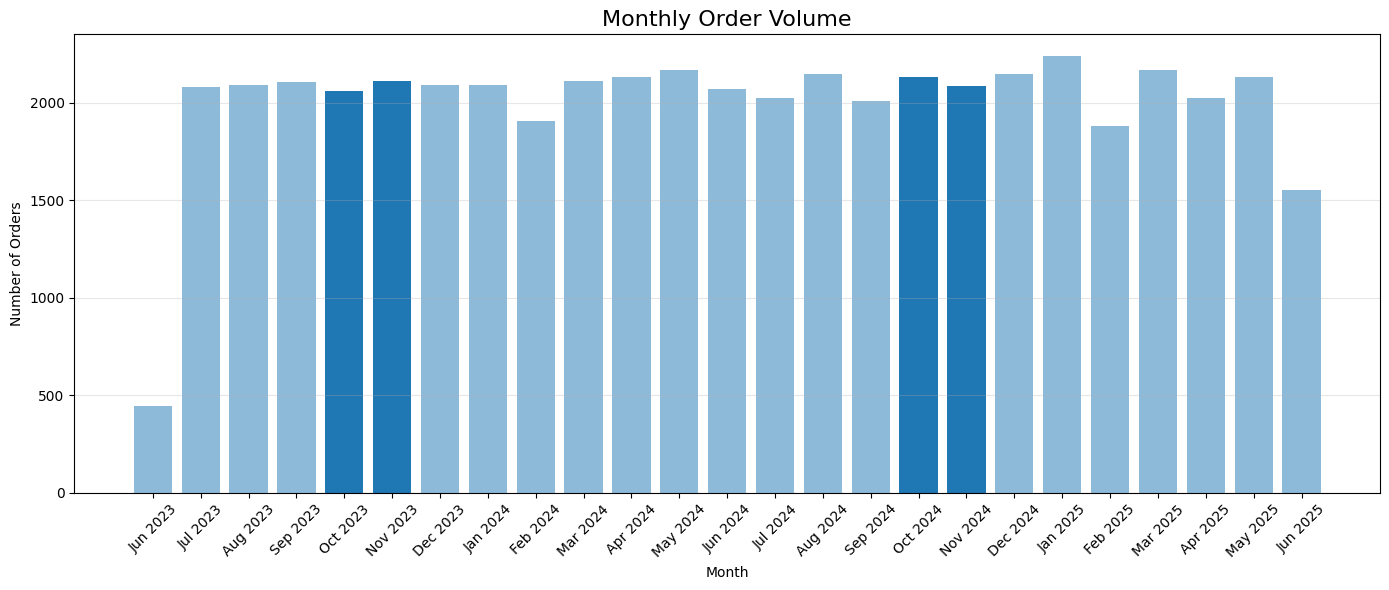

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

bars = plt.bar(
    monthly_orders["month"],
    monthly_orders["order_count"]
)

# Highlight October and November
for bar, period in zip(bars, monthly_orders["order_date"]):
    if period.month in [10, 11]:
        bar.set_alpha(1.0)
    else:
        bar.set_alpha(0.5)

plt.title("Monthly Order Volume", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
plt.savefig(
    "01_monthly_order_volume.png",
    dpi=300,
    bbox_inches="tight"
)


<Figure size 640x480 with 0 Axes>

In [9]:
monthly_orders

,order_date,order_count,month
0,2023-06,444,Jun 2023
1,2023-07,2081,Jul 2023
2,2023-08,2091,Aug 2023
3,2023-09,2104,Sep 2023
4,2023-10,2060,Oct 2023
5,2023-11,2114,Nov 2023
6,2023-12,2090,Dec 2023
7,2024-01,2090,Jan 2024
8,2024-02,1907,Feb 2024
9,2024-03,2111,Mar 2024


In [10]:
monthly_orders.sort_values(
    "order_count",
    ascending=False
).head(5)

,order_date,order_count,month
19,2025-01,2239,Jan 2025
11,2024-05,2167,May 2024
21,2025-03,2167,Mar 2025
18,2024-12,2148,Dec 2024
14,2024-08,2146,Aug 2024


Order volume remained fairly consistent across the 24 months, with January 2025 recording the highest number of orders (2,239).

Monthly Revenue

In [11]:
monthly_revenue = (
    orders
    .groupby(orders["order_date"].dt.to_period("M"))["final_amount"]
    .sum()
    .reset_index()
)

monthly_revenue["month"] = monthly_revenue["order_date"].dt.strftime("%b %Y")

monthly_revenue

,order_date,final_amount,month
0,2023-06,2.738485e+07,Jun 2023
1,2023-07,1.289205e+08,Jul 2023
2,2023-08,1.281220e+08,Aug 2023
3,2023-09,1.374625e+08,Sep 2023
4,2023-10,1.324709e+08,Oct 2023
5,2023-11,1.372634e+08,Nov 2023
6,2023-12,1.369234e+08,Dec 2023
7,2024-01,1.314500e+08,Jan 2024
8,2024-02,1.209459e+08,Feb 2024
9,2024-03,1.336701e+08,Mar 2024


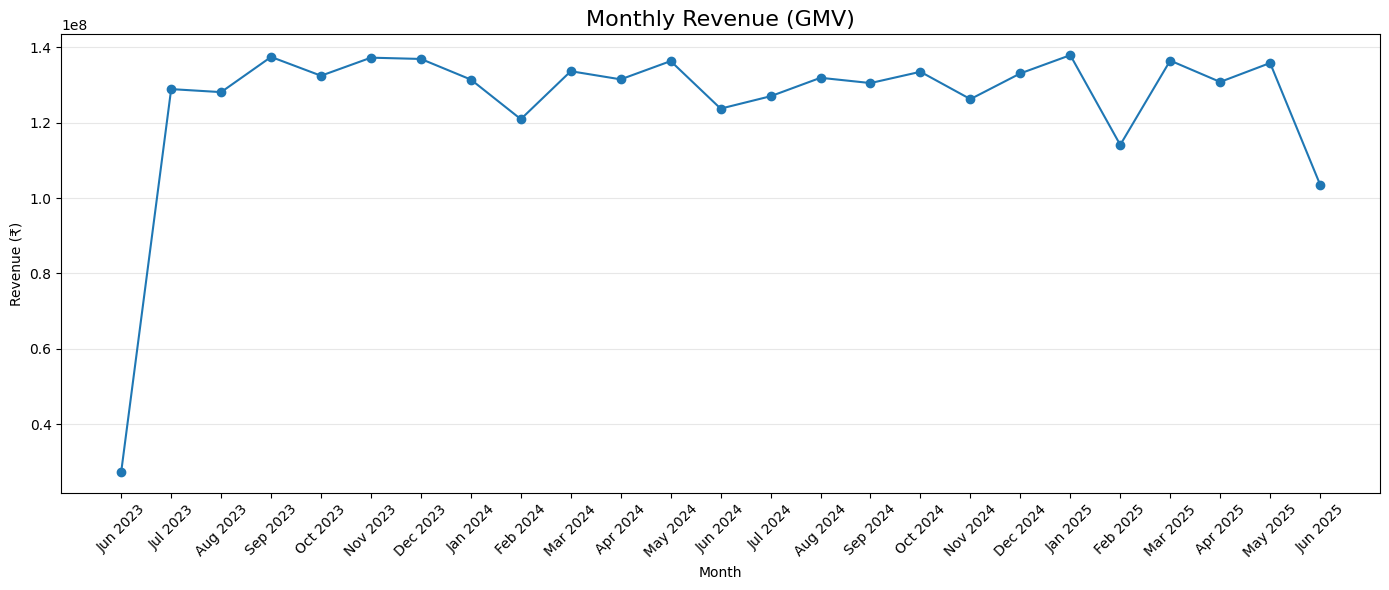

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["final_amount"],
    marker="o"
)

plt.title("Monthly Revenue (GMV)", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
plt.savefig(
    "02_monthly_revenue_gmv.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Category-wise Revenue Share

In [16]:
category_revenue = (
    order_items
    .groupby("category")["total_price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue

,category,total_price
0,Electronics,1.642423e+09
1,Sports & Fitness,4.972384e+08
2,Home & Kitchen,2.442952e+08
3,Fashion,1.481553e+08
4,Automotive,1.234851e+08
5,Office Supplies,9.302935e+07
6,Toys & Baby,4.658385e+07
7,Beauty & Health,3.301811e+07
8,Grocery,1.871868e+07
9,Books,1.394589e+07


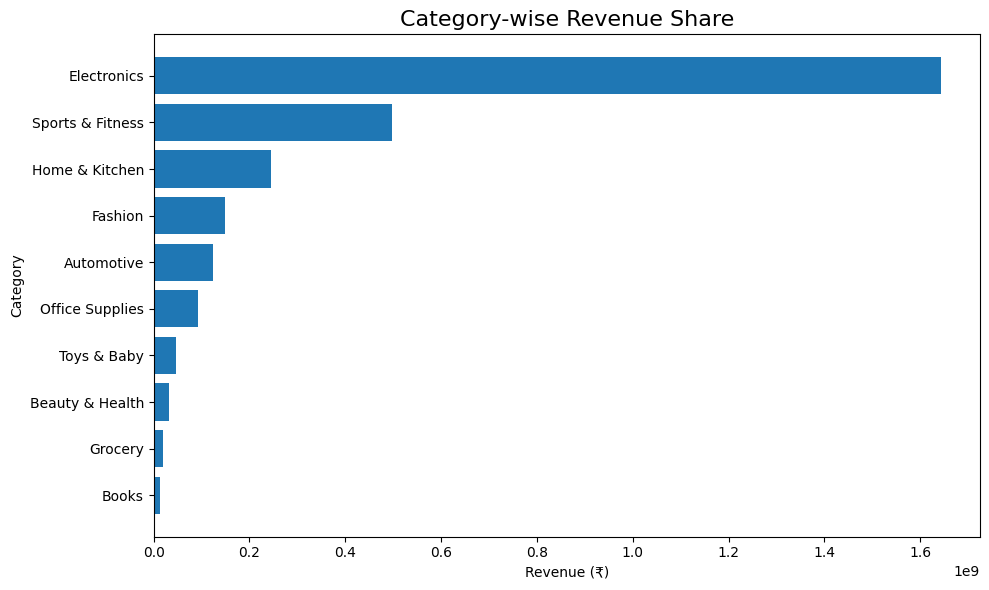

In [17]:
plt.figure(figsize=(10, 6))

plt.barh(
    category_revenue["category"],
    category_revenue["total_price"]
)

plt.title("Category-wise Revenue Share", fontsize=16)
plt.xlabel("Revenue (₹)")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [18]:
plt.savefig(
    "03_category_revenue_share.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [19]:
category_revenue.head(1)

,category,total_price
0,Electronics,1.642423e+09


Electronics generated the highest revenue at approximately ₹1.64 billion, making it the top-performing category.
This indicates strong customer demand for electronics compared with other categories.

Order Status Distribution

In [20]:
status_counts = orders["status"].value_counts()

status_counts

,count
status,
Delivered,32499
Cancelled,5996
Shipped,5071
Returned,3933
Processing,2501


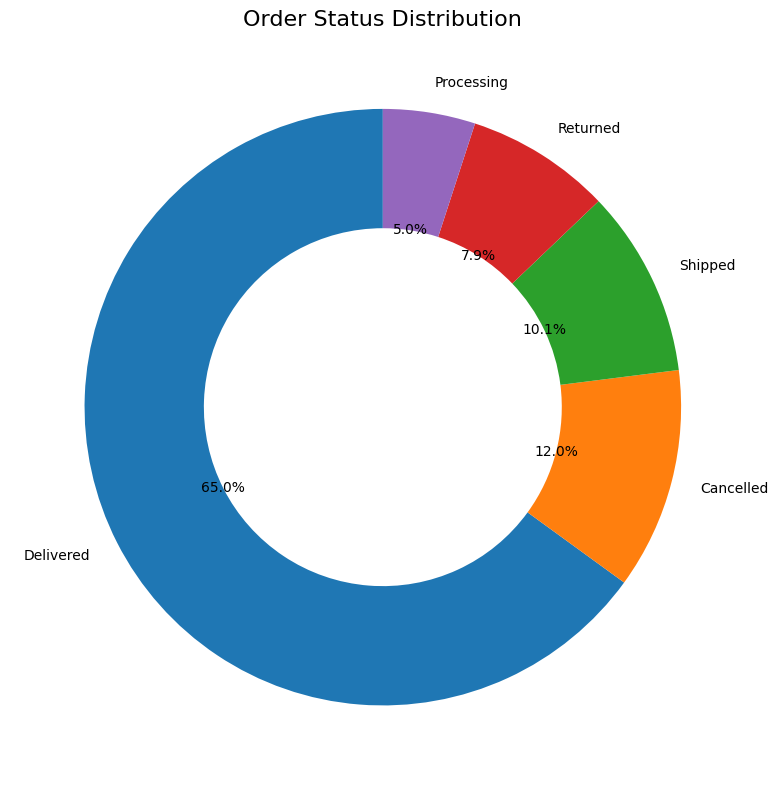

In [21]:
plt.figure(figsize=(8, 8))

plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Order Status Distribution", fontsize=16)

plt.tight_layout()
plt.show()

In [22]:
plt.savefig(
    "04_order_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [23]:
status_percentage = (
    orders["status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

status_percentage


,proportion
status,
Delivered,65.00
Cancelled,11.99
Shipped,10.14
Returned,7.87
Processing,5.00


Delivered orders dominate the dataset at 65%, while 11.99% were cancelled and 7.87% were returned.
This indicates that most orders were successfully completed, although cancellations and returns represent areas for improvement.

Top 10 States by Number of Orders

In [25]:
state_orders = (
    orders["state"]
    .value_counts()
    .head(10)
    .reset_index()
)

state_orders.columns = ["state", "order_count"]

state_orders

,state,order_count
0,Uttar Pradesh,9507
1,Maharashtra,8179
2,Gujarat,3811
3,Madhya Pradesh,3741
4,Tamil Nadu,3664
5,Karnataka,3102
6,Rajasthan,3047
7,West Bengal,2103
8,Punjab,2073
9,Jharkhand,2044


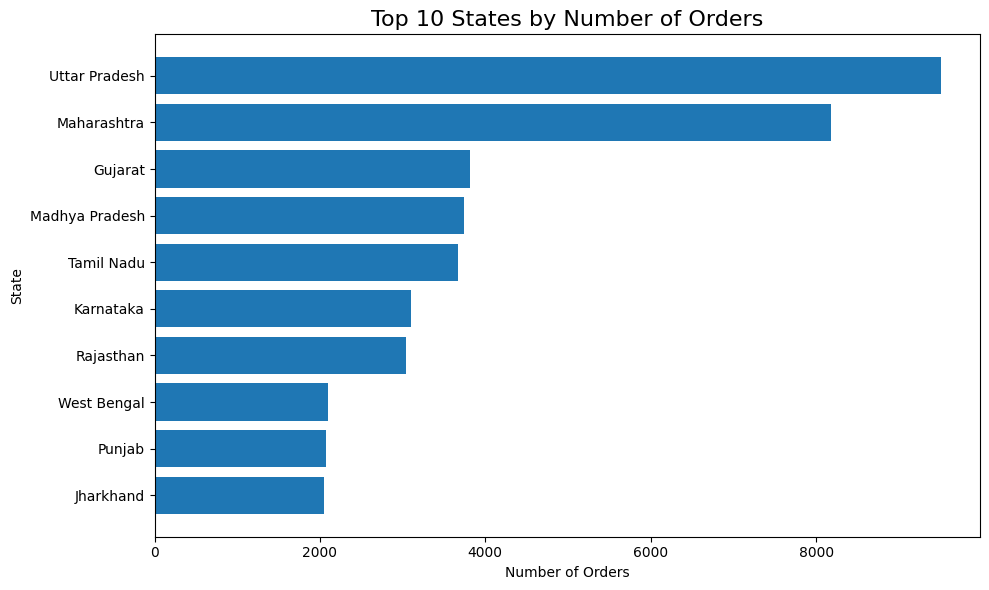

In [26]:
plt.figure(figsize=(10, 6))

plt.barh(
    state_orders["state"],
    state_orders["order_count"]
)

plt.title("Top 10 States by Number of Orders", fontsize=16)
plt.xlabel("Number of Orders")
plt.ylabel("State")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [27]:
plt.savefig(
    "05_top_10_states_by_orders.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Uttar Pradesh recorded the highest number of orders with 9,507, followed by Maharashtra with 8,179 orders.
These two states contribute significantly more orders than the other leading states.

Customer Segment Distribution

In [28]:
segment_counts = customers["segment"].value_counts()

segment_counts

,count
segment,
Regular,4026
Budget,2505
Premium,1501
New,1488
Inactive,480


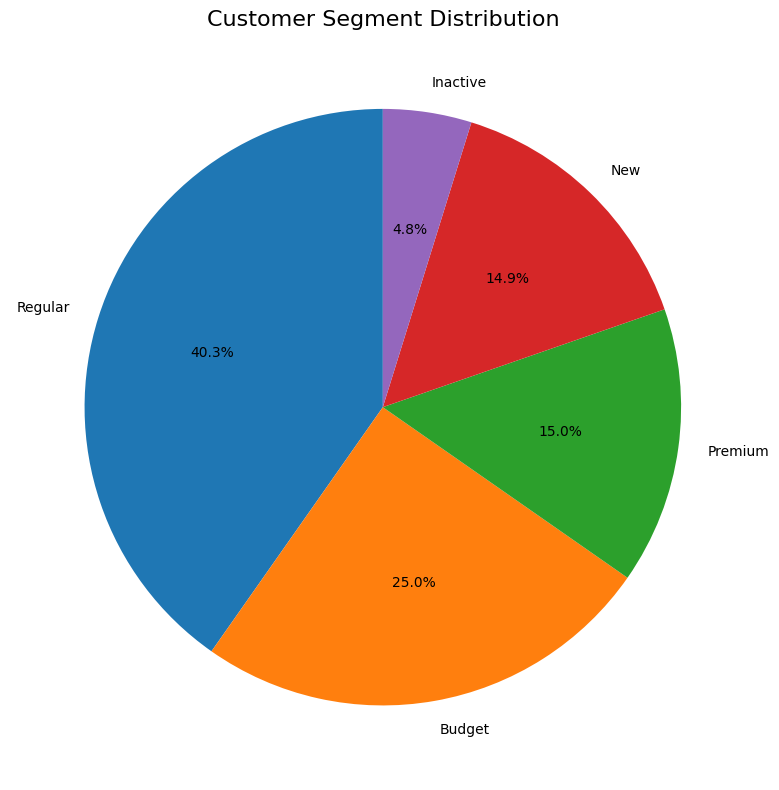

In [29]:
plt.figure(figsize=(8, 8))

plt.pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Segment Distribution", fontsize=16)

plt.tight_layout()
plt.show()

In [30]:
plt.savefig(
    "06_customer_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Regular customers form the largest segment with 4,026 customers, followed by Budget customers with 2,505.
Premium customers account for 1,501 customers, indicating a smaller but valuable customer group.


Payment Method Usage

In [32]:
payment_methods = payments["payment_method"].value_counts()

payment_methods

,count
payment_method,
UPI,17570
Credit Card,10007
Debit Card,7624
Cash on Delivery,5883
Net Banking,4026
EMI,2943
Wallet,1947


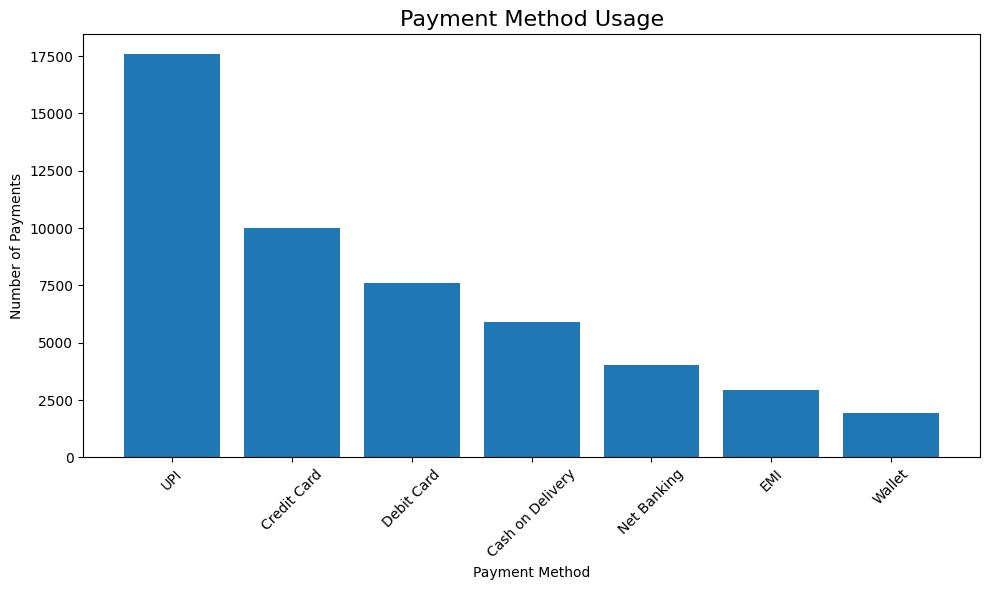

In [33]:
plt.figure(figsize=(10, 6))

plt.bar(
    payment_methods.index,
    payment_methods.values
)

plt.title("Payment Method Usage", fontsize=16)
plt.xlabel("Payment Method")
plt.ylabel("Number of Payments")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [34]:
plt.savefig(
    "07_payment_method_usage.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

UPI is the most-used payment method with 17,570 payments, followed by Credit Card with 10,007.
This shows a strong preference for digital payment methods, especially UPI.

Age Distribution

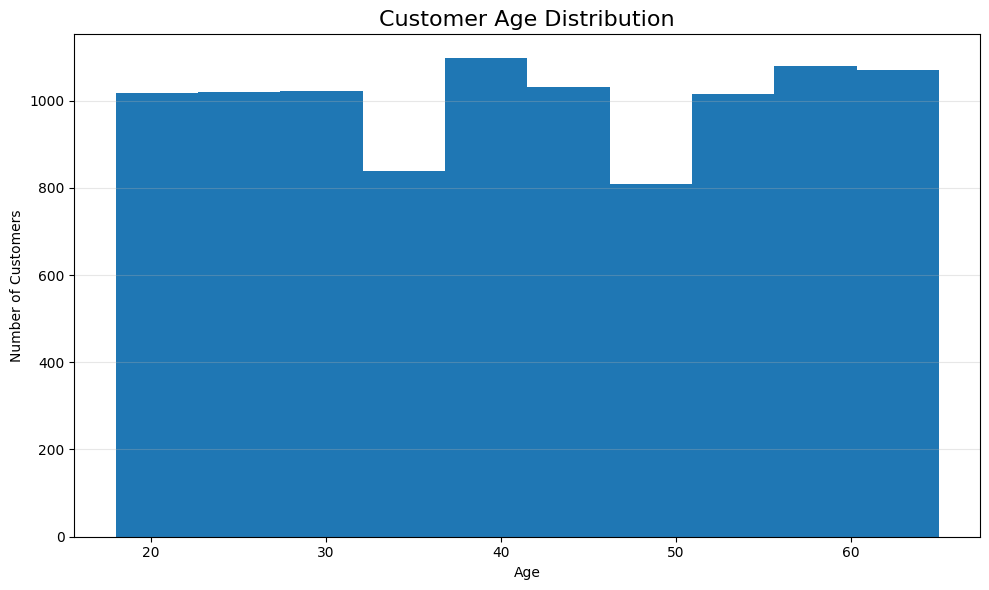

In [35]:
plt.figure(figsize=(10, 6))

plt.hist(customers["age"], bins=10)

plt.title("Customer Age Distribution", fontsize=16)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
plt.savefig(
    "08_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Customers are fairly evenly distributed across ages 18–65, with no major concentration in a single age group.
This indicates the e-commerce business attracts customers across a broad age range.

Return Reasons

In [37]:
return_reasons = returns["reason"].value_counts()
return_reasons

,count
reason,
Size Issue,1196
Changed Mind,1150
Damaged in Transit,1143
Wrong Product Delivered,1135
Defective Product,1134
Not as Described,1125
Duplicate Order,1081
Quality Issue,1075
Delayed Delivery,484


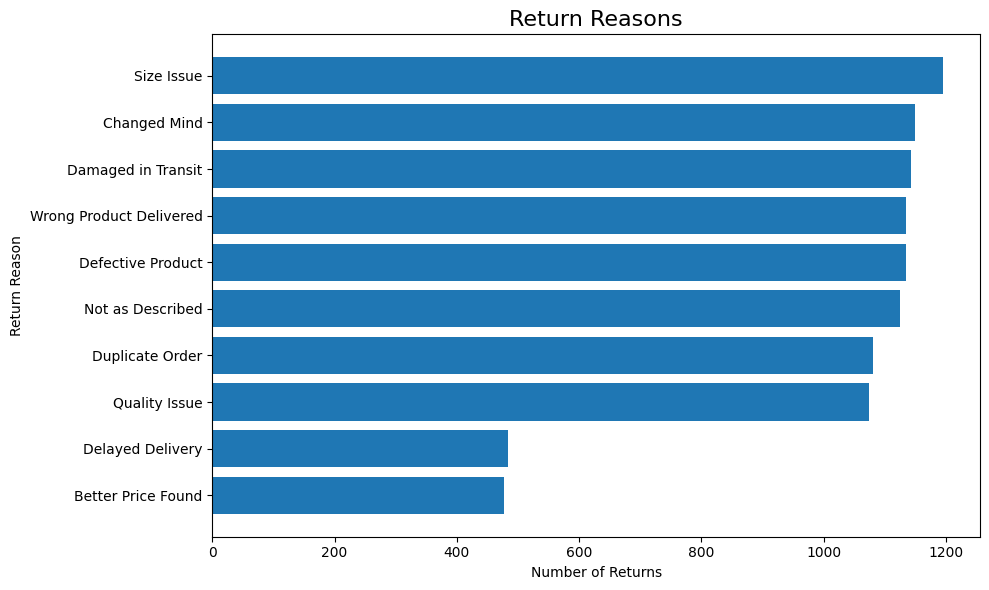

In [39]:
plt.figure(figsize=(10, 6))

plt.barh(return_reasons.index, return_reasons.values)

plt.title("Return Reasons", fontsize=16)
plt.xlabel("Number of Returns")
plt.ylabel("Return Reason")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [40]:
plt.savefig(
    "09_return_reasons.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Size Issue is the most common return reason with 1,196 returns, followed by Changed Mind with 1,150.
Delayed Delivery and Better Price Found are the least common reasons.

Average Order Value (AOV) for each customer segment

In [41]:
segment_aov = (
    orders
    .merge(
        customers[["customer_id", "segment"]],
        on="customer_id",
        how="left"
    )
    .groupby("segment")["final_amount"]
    .mean()
    .sort_values(ascending=False)
)

segment_aov

,final_amount
segment,
Budget,64124.558428
New,63381.577666
Regular,63123.549510
Premium,61876.903871
Inactive,57120.144096


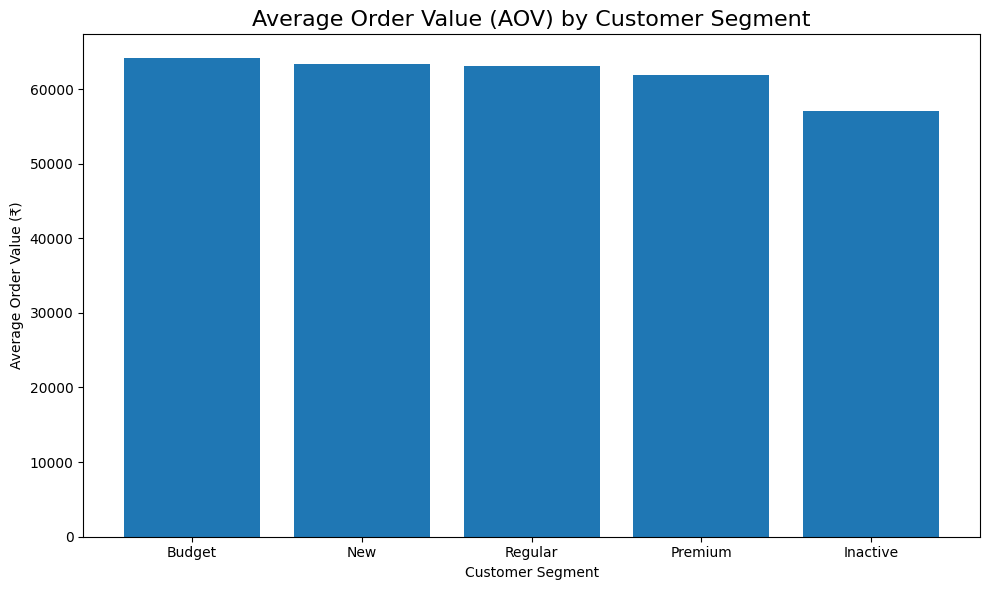

In [42]:
plt.figure(figsize=(10, 6))

plt.bar(segment_aov.index, segment_aov.values)

plt.title("Average Order Value (AOV) by Customer Segment", fontsize=16)
plt.xlabel("Customer Segment")
plt.ylabel("Average Order Value (₹)")

plt.tight_layout()
plt.show()

In [43]:
plt.savefig(
    "10_aov_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Budget customers have the highest AOV at approximately ₹64,125, while Inactive customers have the lowest at ₹57,120.
Interestingly, Premium customers do not have the highest AOV in this dataset.